In [2]:
from pathlib import Path
import sys
import warnings

import joblib
import pandas as pd
from scipy import sparse

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import ParameterGrid, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
X_TRAIN_PATH = DATA_DIR / "X_train.npz"
X_TEST_PATH = DATA_DIR / "X_test.npz"
Y_TRAIN_PATH = DATA_DIR / "y_train.csv"
Y_TEST_PATH = DATA_DIR / "y_test.csv"
LABEL_ENCODER_PATH = DATA_DIR / "label_encoder.joblib"
BEST_MODEL_PATH = DATA_DIR / "best_sentiment_model.joblib"
MODEL_RESULTS_PATH = DATA_DIR / "model_results.csv"
RANDOM_STATE = 42
MAX_GENERALIZATION_GAP = 0.08

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")


 ------------------------------------------------------------------
 1. Load feature-engineered data
 ------------------------------------------------------------------


In [3]:
X_train = sparse.load_npz(X_TRAIN_PATH)
X_test = sparse.load_npz(X_TEST_PATH)
y_train_df = pd.read_csv(Y_TRAIN_PATH)
y_test_df = pd.read_csv(Y_TEST_PATH)
y_train = y_train_df["label"]
y_test = y_test_df["label"]
le = joblib.load(LABEL_ENCODER_PATH)

if X_train.shape[0] != len(y_train):
    raise ValueError(f"X_train rows ({X_train.shape[0]}) != y_train rows ({len(y_train)})")
if X_test.shape[0] != len(y_test):
    raise ValueError(f"X_test rows ({X_test.shape[0]}) != y_test rows ({len(y_test)})")

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Classes:", list(le.classes_))
print("Train distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("Test distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))


X_train: (72381, 40000)  X_test: (18096, 40000)
Classes: ['Negative', 'Neutral', 'Positive']
Train distribution:
label
0    0.358
1    0.314
2    0.328
Name: proportion, dtype: float64
Test distribution:
label
0    0.358
1    0.314
2    0.328
Name: proportion, dtype: float64


 ------------------------------------------------------------------
 2. Tune candidate text classifiers for generalization
Each algorithm is tuned internally, then only the best generalized parameter set for each model is shown: Linear SVM, Logistic Regression, and Complement Naive Bayes.
 ------------------------------------------------------------------


In [4]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

candidate_grids = {
    "Linear SVM": {
        "estimator": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
        "params": {"C": [0.01, 0.02, 0.03, 0.05, 0.075, 0.1]},
    },
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
        "params": {"C": [0.1, 0.25, 0.5]},
    },
    
    "Complement Naive Bayes": {
        "estimator": ComplementNB(),
        "params": {"alpha": [0.1, 0.5, 1.0]},
    },
}

all_results = []
trained_models = {}

for name, cfg in candidate_grids.items():
    print(f"Tuning {name} ...")
    for params in ParameterGrid(cfg["params"]):
        model = clone(cfg["estimator"]).set_params(**params)

        cv_scores = cross_val_score(model, X_train, y_train, scoring="f1_macro", cv=cv, n_jobs=1)
        model.fit(X_train, y_train)

        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)

        train_acc = accuracy_score(y_train, train_preds)
        test_acc = accuracy_score(y_test, test_preds)
        train_test_gap = train_acc - test_acc
        f1_macro = f1_score(y_test, test_preds, average="macro")
        f1_weighted = f1_score(y_test, test_preds, average="weighted")
        generalization_ok = train_test_gap <= MAX_GENERALIZATION_GAP

        model_key = f"{name} | {params}"
        trained_models[model_key] = model
        all_results.append({
            "model": name,
            "cv_f1_macro": cv_scores.mean(),
            "cv_f1_std": cv_scores.std(),
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "train_test_gap": train_test_gap,
            "generalization_ok": generalization_ok,
            "f1_macro": f1_macro,
            "f1_weighted": f1_weighted,
            "best_params": params,
            "model_key": model_key,
        })

all_results_df = pd.DataFrame(all_results)

best_rows = []
for model_name, model_results in all_results_df.groupby("model", sort=False):
    eligible = model_results[model_results["generalization_ok"]].copy()
    selection_df = eligible if not eligible.empty else model_results.copy()
    best_row = selection_df.sort_values(
        ["f1_macro", "cv_f1_macro", "train_test_gap"],
        ascending=[False, False, True],
    ).iloc[0]
    best_rows.append(best_row)

results_df = pd.DataFrame(best_rows).sort_values(
    ["f1_macro", "cv_f1_macro"],
    ascending=[False, False],
).reset_index(drop=True)

best_model_key = results_df.iloc[0]["model_key"]
results_df.drop(columns=["model_key"])


Tuning Linear SVM ...
Tuning Logistic Regression ...
Tuning Complement Naive Bayes ...


,model,cv_f1_macro,cv_f1_std,train_accuracy,test_accuracy,train_test_gap,generalization_ok,f1_macro,f1_weighted,best_params
0,Linear SVM,0.668355,0.004070,0.753706,0.682637,0.071069,True,0.682376,0.683546,{'C': 0.05}
1,Logistic Regression,0.665346,0.003539,0.741161,0.679321,0.061840,True,0.679789,0.680765,{'C': 0.25}
2,Complement Naive Bayes,0.635381,0.001750,0.684475,0.638870,0.045605,True,0.631962,0.634255,{'alpha': 0.5}


 ------------------------------------------------------------------
 3. Compare models visually
 ------------------------------------------------------------------


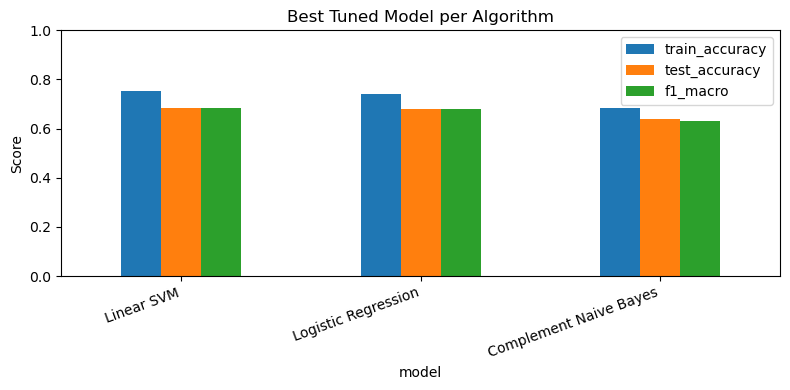

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
results_df.set_index("model")[["train_accuracy", "test_accuracy", "f1_macro"]].plot(kind="bar", ax=ax)
ax.set_title("Best Tuned Model per Algorithm")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


 ------------------------------------------------------------------
 4. Save the best model for evaluation
 ------------------------------------------------------------------


In [6]:
best_row = results_df.loc[results_df["model_key"].eq(best_model_key)].iloc[0]
best_model = trained_models[best_model_key]

joblib.dump(best_model, BEST_MODEL_PATH)
results_df.drop(columns=["model_key"]).to_csv(MODEL_RESULTS_PATH, index=False)

print(f"Best generalized model: {best_row['model']} {best_row['best_params']}")
print(f"Train accuracy: {best_row['train_accuracy']:.4f}")
print(f"Test accuracy: {best_row['test_accuracy']:.4f}")
print(f"Train/test gap: {best_row['train_test_gap']:.4f}")
print(f"Macro F1: {best_row['f1_macro']:.4f}")
print(f"Saved model to {BEST_MODEL_PATH}")
print(f"Saved three-row model comparison to {MODEL_RESULTS_PATH}")

best_preds = best_model.predict(X_test)
print("\nClassification report for best generalized model:")
print(classification_report(y_test, best_preds, target_names=le.classes_))


Best generalized model: Linear SVM {'C': 0.05}
Train accuracy: 0.7537
Test accuracy: 0.6826
Train/test gap: 0.0711
Macro F1: 0.6824
Saved model to /Users/saanvimehta/Downloads/Comments Sentimental Analysis /data/best_sentiment_model.joblib
Saved three-row model comparison to /Users/saanvimehta/Downloads/Comments Sentimental Analysis /data/model_results.csv

Classification report for best generalized model:
              precision    recall  f1-score   support

    Negative       0.67      0.71      0.69      6480
     Neutral       0.61      0.63      0.62      5680
    Positive       0.77      0.69      0.73      5936

    accuracy                           0.68     18096
   macro avg       0.69      0.68      0.68     18096
weighted avg       0.69      0.68      0.68     18096

